# Cardiac Risk Detection — ECG & Physiological Feature Analysis

This notebook analyzes ECG and physiological features to assess cardiac risk.
**Workflow:** Data Loading → Cleaning → Feature Engineering → Correlation Analysis → Visualization → Report

In [ ]:
%pip install xgboost openpyxl matplotlib seaborn scikit-learn pandas numpy scipy -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile

from sklearn.preprocessing import LabelEncoder
from scipy.io import loadmat

---
## 1. Load Dataset (Clinical Features)

In [3]:
pf_df = pd.read_excel("dataset-1.xlsx", header=1)

# Drop unnamed columns and standardize column names
pf_df = pf_df.loc[:, ~pf_df.columns.str.contains('^Unnamed', na=False)]
pf_df.columns = [str(col).strip() for col in pf_df.columns]

pf_df.head()

,Age (years),Weight (Kg),Height (cm),Race,SysBP (mmHg),DiaBP (mmHg),VentricularRate (bpm),PQInterval (ms),QRSDuration (ms),QTInterval (ms),...,III,aVR,aVL,aVF,V1,V2,V3,V4,V5,V6
0,37,84,183,Caucasian,105,70,55,196,110,448,...,NaN,X,NaN,NaN,X,NaN,NaN,NaN,NaN,NaN
1,23,77,184,Caucasian,107,75,62,280,92,414,...,NaN,X,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,29,75,183,Caucasian,105,70,55,158,110,432,...,NaN,X,NaN,NaN,X,NaN,NaN,NaN,NaN,NaN
3,32,82,187,Caucasian,123,83,47,152,100,430,...,NaN,X,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,35,72,184,Caucasian,106,79,38,194,106,494,...,NaN,X,NaN,NaN,X,NaN,NaN,NaN,NaN,NaN


In [4]:
print(f"Dataset shape: {pf_df.shape}")
print(f"Columns: {pf_df.columns.tolist()}")

Dataset shape: (57, 29)
Columns: ['Age (years)', 'Weight (Kg)', 'Height (cm)', 'Race', 'SysBP (mmHg)', 'DiaBP (mmHg)', 'VentricularRate (bpm)', 'PQInterval (ms)', 'QRSDuration (ms)', 'QTInterval (ms)', 'QTCInterval (ms)', 'RRInterval (ms)', 'PPInterval (ms)', 'Paxis (º)', 'RAxis (º)', 'TAxis (º)', 'VentricularRate (bpm).1', 'I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


---
## 2. Data Cleaning & Standardization

In [5]:
# Standardize column names: map verbose names to concise names
rename_map = {
    'Age (years)': 'Age',
    'Weight (Kg)': 'Weight',
    'Height (cm)': 'Height',
    'SysBP (mmHg)': 'SysBP',
    'DiaBP (mmHg)': 'DiaBP',
    'VentricularRate (bpm)': 'VentricularRate',
    'PQInterval (ms)': 'PQInterval',
    'QRSDuration (ms)': 'QRSDuration',
    'QTInterval (ms)': 'QTInterval',
    'QTCInterval (ms)': 'QTCInterval',
    'RRInterval (ms)': 'RRInterval',
    'PPInterval (ms)': 'PPInterval',
    'Paxis (\u00ba)': 'Paxis',
    'RAxis (\u00ba)': 'RAxis',
    'TAxis (\u00ba)': 'TAxis'
}
pf_df.rename(columns={k: v for k, v in rename_map.items() if k in pf_df.columns}, inplace=True)

# Remove duplicate columns (keep first occurrence)
pf_df = pf_df.loc[:, ~pf_df.columns.duplicated(keep='first')]

In [6]:
# Convert critical columns to numeric (coerce errors to NaN)
numeric_cols = [
    'Age', 'Weight', 'Height', 'SysBP', 'DiaBP', 'VentricularRate',
    'PQInterval', 'QRSDuration', 'QTInterval', 'QTCInterval',
    'RRInterval', 'PPInterval'
]
for col in numeric_cols:
    if col in pf_df.columns:
        pf_df[col] = pd.to_numeric(pf_df[col], errors='coerce')

In [7]:
# Encode Race column to numeric
if 'Race' in pf_df.columns and not pd.api.types.is_numeric_dtype(pf_df['Race']):
    encoder = LabelEncoder()
    pf_df['Race'] = encoder.fit_transform(pf_df['Race'].astype(str))

In [8]:
# Fill missing values and remove duplicate rows
pf_df = pf_df.fillna(0)
pf_df = pf_df.drop_duplicates()

print(f"Final shape after cleaning: {pf_df.shape}")
print(f"\nData types:\n{pf_df.dtypes}")

Final shape after cleaning: (57, 29)

Data types:
Age                        float64
Weight                     float64
Height                     float64
Race                         int64
SysBP                      float64
DiaBP                      float64
VentricularRate            float64
PQInterval                 float64
QRSDuration                float64
QTInterval                 float64
QTCInterval                float64
RRInterval                 float64
PPInterval                 float64
Paxis                       object
RAxis                       object
TAxis                       object
VentricularRate (bpm).1     object
I                          float64
II                         float64
III                         object
aVR                         object
aVL                        float64
aVF                        float64
V1                          object
V2                          object
V3                          object
V4                          object
V5   

---
## 3. Feature Engineering

In [9]:
# BMI = weight(kg) / height(m)^2
if 'Weight' in pf_df.columns and 'Height' in pf_df.columns:
    pf_df['BMI'] = pf_df['Weight'] / ((pf_df['Height'] / 100) ** 2)

# MAP = (SBP + 2 * DBP) / 3
if 'SysBP' in pf_df.columns and 'DiaBP' in pf_df.columns:
    pf_df['MAP'] = (pf_df['SysBP'] + 2 * pf_df['DiaBP']) / 3

print("BMI and MAP calculated.")

BMI and MAP calculated.


In [10]:
# Create Cardiac Risk labels based on QT Interval thresholds:
#   Normal: < 400ms  |  Moderate Risk: 400-450ms  |  High Risk: >= 450ms
conditions = [
    pf_df['QTInterval'] < 400,
    (pf_df['QTInterval'] >= 400) & (pf_df['QTInterval'] < 450),
    pf_df['QTInterval'] >= 450
]
labels = ['Normal', 'Moderate Risk', 'High Risk']

pf_df['CardiacRisk'] = np.select(conditions, labels, default='Unknown')

risk_mapping = {'Normal': 0, 'Moderate Risk': 1, 'High Risk': 2, 'Unknown': -1}
pf_df['CardiacRisk_Encoded'] = pf_df['CardiacRisk'].map(risk_mapping)

print("Cardiac Risk labels created.")
print(pf_df['CardiacRisk'].value_counts())

Cardiac Risk labels created.
CardiacRisk
Moderate Risk    34
High Risk        13
Normal           10
Name: count, dtype: int64


---
## 4. Dataset Overview & Validation

In [11]:
print(f"Dataset shape: {pf_df.shape}")
print(f"\nColumns: {pf_df.columns.tolist()}")

numeric_cols = pf_df.select_dtypes(include=np.number).columns.tolist()
object_cols = pf_df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"\nNumeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"Object/Categorical columns ({len(object_cols)}): {object_cols}")

missing = pf_df.isnull().sum()
missing = missing[missing > 0]
if not missing.empty:
    print(f"\nMissing values:\n{missing}")
else:
    print("\nNo missing values.")

pf_df.info()

Dataset shape: (57, 33)

Columns: ['Age', 'Weight', 'Height', 'Race', 'SysBP', 'DiaBP', 'VentricularRate', 'PQInterval', 'QRSDuration', 'QTInterval', 'QTCInterval', 'RRInterval', 'PPInterval', 'Paxis', 'RAxis', 'TAxis', 'VentricularRate (bpm).1', 'I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'BMI', 'MAP', 'CardiacRisk', 'CardiacRisk_Encoded']

Numeric columns (20): ['Age', 'Weight', 'Height', 'Race', 'SysBP', 'DiaBP', 'VentricularRate', 'PQInterval', 'QRSDuration', 'QTInterval', 'QTCInterval', 'RRInterval', 'PPInterval', 'I', 'II', 'aVL', 'aVF', 'BMI', 'MAP', 'CardiacRisk_Encoded']
Object/Categorical columns (13): ['Paxis', 'RAxis', 'TAxis', 'VentricularRate (bpm).1', 'III', 'aVR', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'CardiacRisk']

Missing values:
BMI    1
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------

C:\Users\R.SELLAMUTHU\AppData\Local\Temp\ipykernel_22000\301615643.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = pf_df.select_dtypes(include=['object', 'category']).columns.tolist()


---
## 5. Correlation Analysis

In [12]:
# Compute Pearson correlation matrix for all numeric features
corr_matrix = pf_df.select_dtypes(include=np.number).corr(method='pearson')
print(f"Correlation matrix shape: {corr_matrix.shape}")
corr_matrix.head()

Correlation matrix shape: (20, 20)


,Age,Weight,Height,Race,SysBP,DiaBP,VentricularRate,PQInterval,QRSDuration,QTInterval,QTCInterval,RRInterval,PPInterval,I,II,aVL,aVF,BMI,MAP,CardiacRisk_Encoded
Age,1.000000,0.660133,0.652878,-0.181577,0.326236,0.298936,0.116239,0.214847,0.281403,0.420313,0.333098,0.390347,0.395779,NaN,NaN,NaN,NaN,-0.475633,0.319968,0.263512
Weight,0.660133,1.000000,0.953481,-0.389145,0.468684,0.469870,0.385581,0.353452,0.419305,0.420332,0.452897,0.299479,0.301254,NaN,NaN,NaN,NaN,-0.805350,0.483098,0.105342
Height,0.652878,0.953481,1.000000,-0.470553,0.469869,0.487194,0.366273,0.350482,0.459263,0.463234,0.470612,0.354892,0.357478,NaN,NaN,NaN,NaN,-0.959687,0.493671,0.160064
Race,-0.181577,-0.389145,-0.470553,1.000000,-0.369180,-0.489745,-0.165070,-0.356246,-0.509931,-0.541576,-0.444201,-0.486209,-0.486620,NaN,NaN,NaN,NaN,0.428995,-0.449867,-0.430374
SysBP,0.326236,0.468684,0.469869,-0.369180,1.000000,0.885993,0.633591,0.522716,0.804654,0.837519,0.856781,0.604680,0.608749,NaN,NaN,NaN,NaN,0.024480,0.963212,0.225383


In [13]:
# Correlation of each feature with CardiacRisk_Encoded
corr_risk = corr_matrix['CardiacRisk_Encoded'].sort_values(ascending=False)
print("Correlation with CardiacRisk_Encoded (sorted):")
corr_risk

Correlation with CardiacRisk_Encoded (sorted):


CardiacRisk_Encoded    1.000000
RRInterval             0.716592
PPInterval             0.713972
QTInterval             0.593468
QRSDuration            0.344242
DiaBP                  0.293029
MAP                    0.271189
QTCInterval            0.270319
Age                    0.263512
SysBP                  0.225383
Height                 0.160064
PQInterval             0.152732
Weight                 0.105342
BMI                   -0.016467
VentricularRate       -0.286248
Race                  -0.430374
I                           NaN
II                          NaN
aVL                         NaN
aVF                         NaN
Name: CardiacRisk_Encoded, dtype: float64

In [14]:
# Build correlation percentage table (absolute strength)
correlation_df = corr_risk.drop('CardiacRisk_Encoded', errors='ignore').to_frame(name='Correlation')
correlation_df['Abs Correlation'] = correlation_df['Correlation'].abs()
correlation_df['Correlation (%)'] = correlation_df['Abs Correlation'] * 100
correlation_df = correlation_df.sort_values(by='Correlation (%)', ascending=False)

print("Feature ranking by absolute correlation with CardiacRisk:")
correlation_df

Feature ranking by absolute correlation with CardiacRisk:


,Correlation,Abs Correlation,Correlation (%)
RRInterval,0.716592,0.716592,71.659162
PPInterval,0.713972,0.713972,71.397183
QTInterval,0.593468,0.593468,59.346764
Race,-0.430374,0.430374,43.037370
QRSDuration,0.344242,0.344242,34.424169
DiaBP,0.293029,0.293029,29.302927
VentricularRate,-0.286248,0.286248,28.624753
MAP,0.271189,0.271189,27.118895
QTCInterval,0.270319,0.270319,27.031934
Age,0.263512,0.263512,26.351177


---
## 6. Visualizations

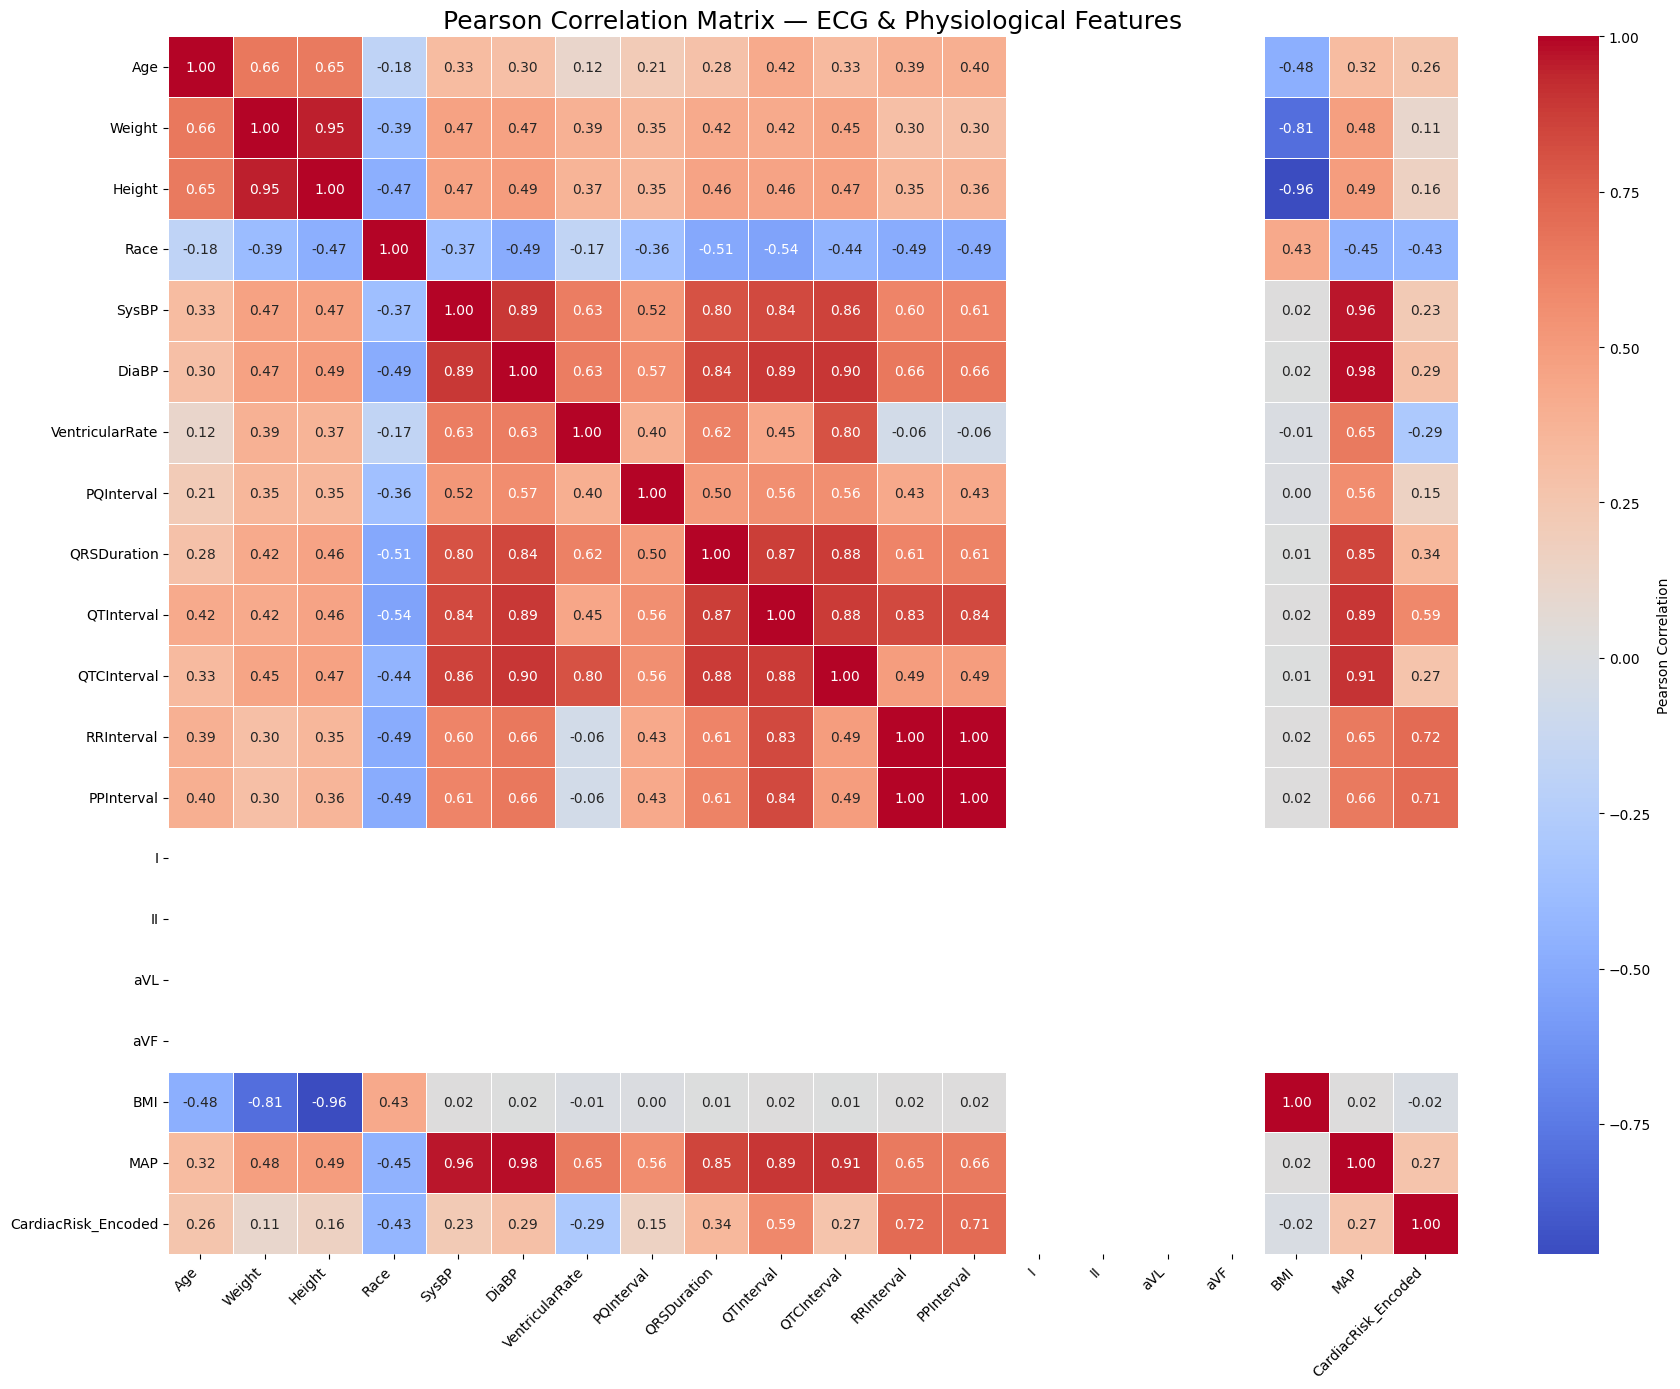

In [15]:
# 6a. Full Correlation Heatmap
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=.5, cbar_kws={'label': 'Pearson Correlation'})
plt.title('Pearson Correlation Matrix — ECG & Physiological Features', fontsize=18)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

C:\Users\R.SELLAMUTHU\AppData\Local\Temp\ipykernel_22000\4093217969.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')


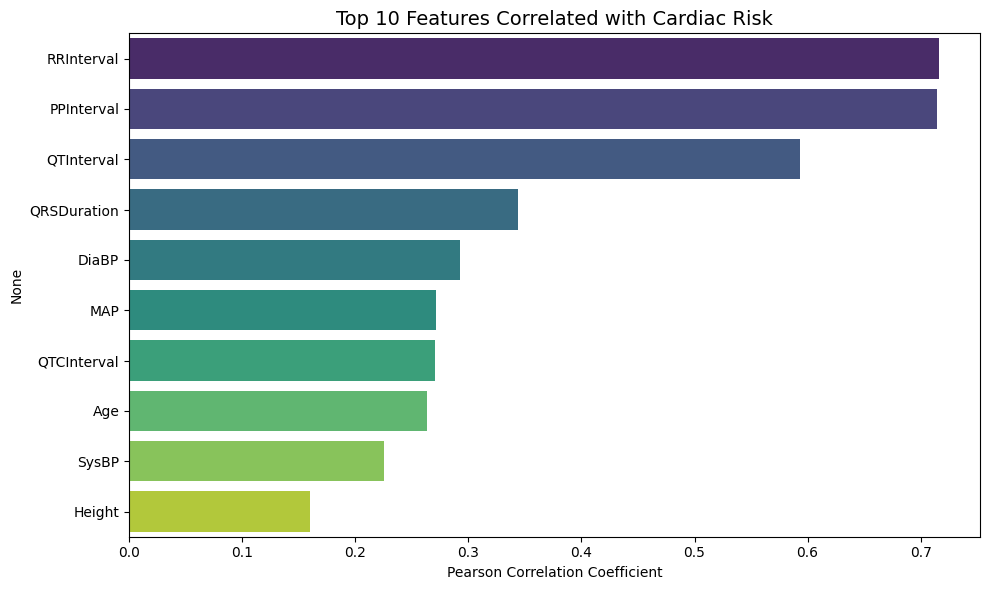

In [16]:
# 6b. Top 10 features correlated with CardiacRisk
top_features = corr_risk.drop('CardiacRisk_Encoded', errors='ignore').head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_features.values, y=top_features.index, hue=top_features.index, palette='viridis', legend=False)
plt.title('Top 10 Features Correlated with Cardiac Risk', fontsize=14)
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.show()

C:\Users\R.SELLAMUTHU\AppData\Local\Temp\ipykernel_22000\1406255281.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=pf_df, x='CardiacRisk',


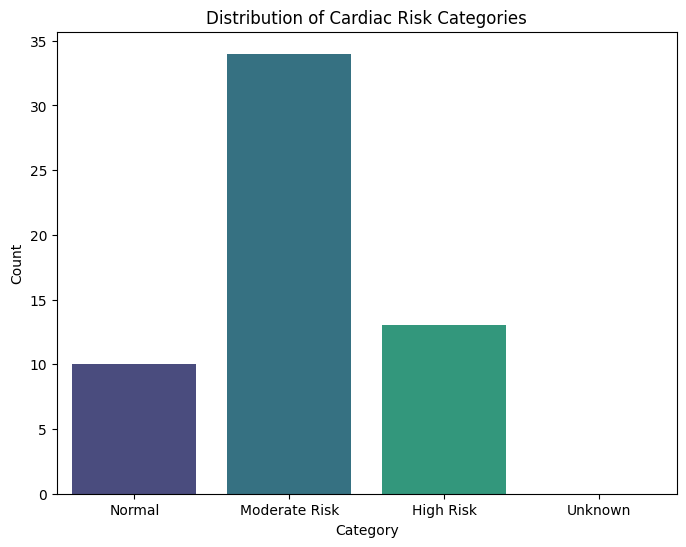

In [17]:
# 6c. Cardiac Risk Class Distribution
plt.figure(figsize=(8, 6))
sns.countplot(data=pf_df, x='CardiacRisk',
              order=['Normal', 'Moderate Risk', 'High Risk', 'Unknown'],
              hue='CardiacRisk', palette='viridis', legend=False)

plt.title('Distribution of Cardiac Risk Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

C:\Users\R.SELLAMUTHU\AppData\Local\Temp\ipykernel_22000\2764133177.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr_plot['Correlation (%)'], y=top_corr_plot.index,
C:\Users\R.SELLAMUTHU\AppData\Local\Temp\ipykernel_22000\2764133177.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=combined.values, y=combined.index, ax=axes[1,0], palette='RdYlGn')
C:\Users\R.SELLAMUTHU\AppData\Local\Temp\ipykernel_22000\2764133177.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=axes[1,1],


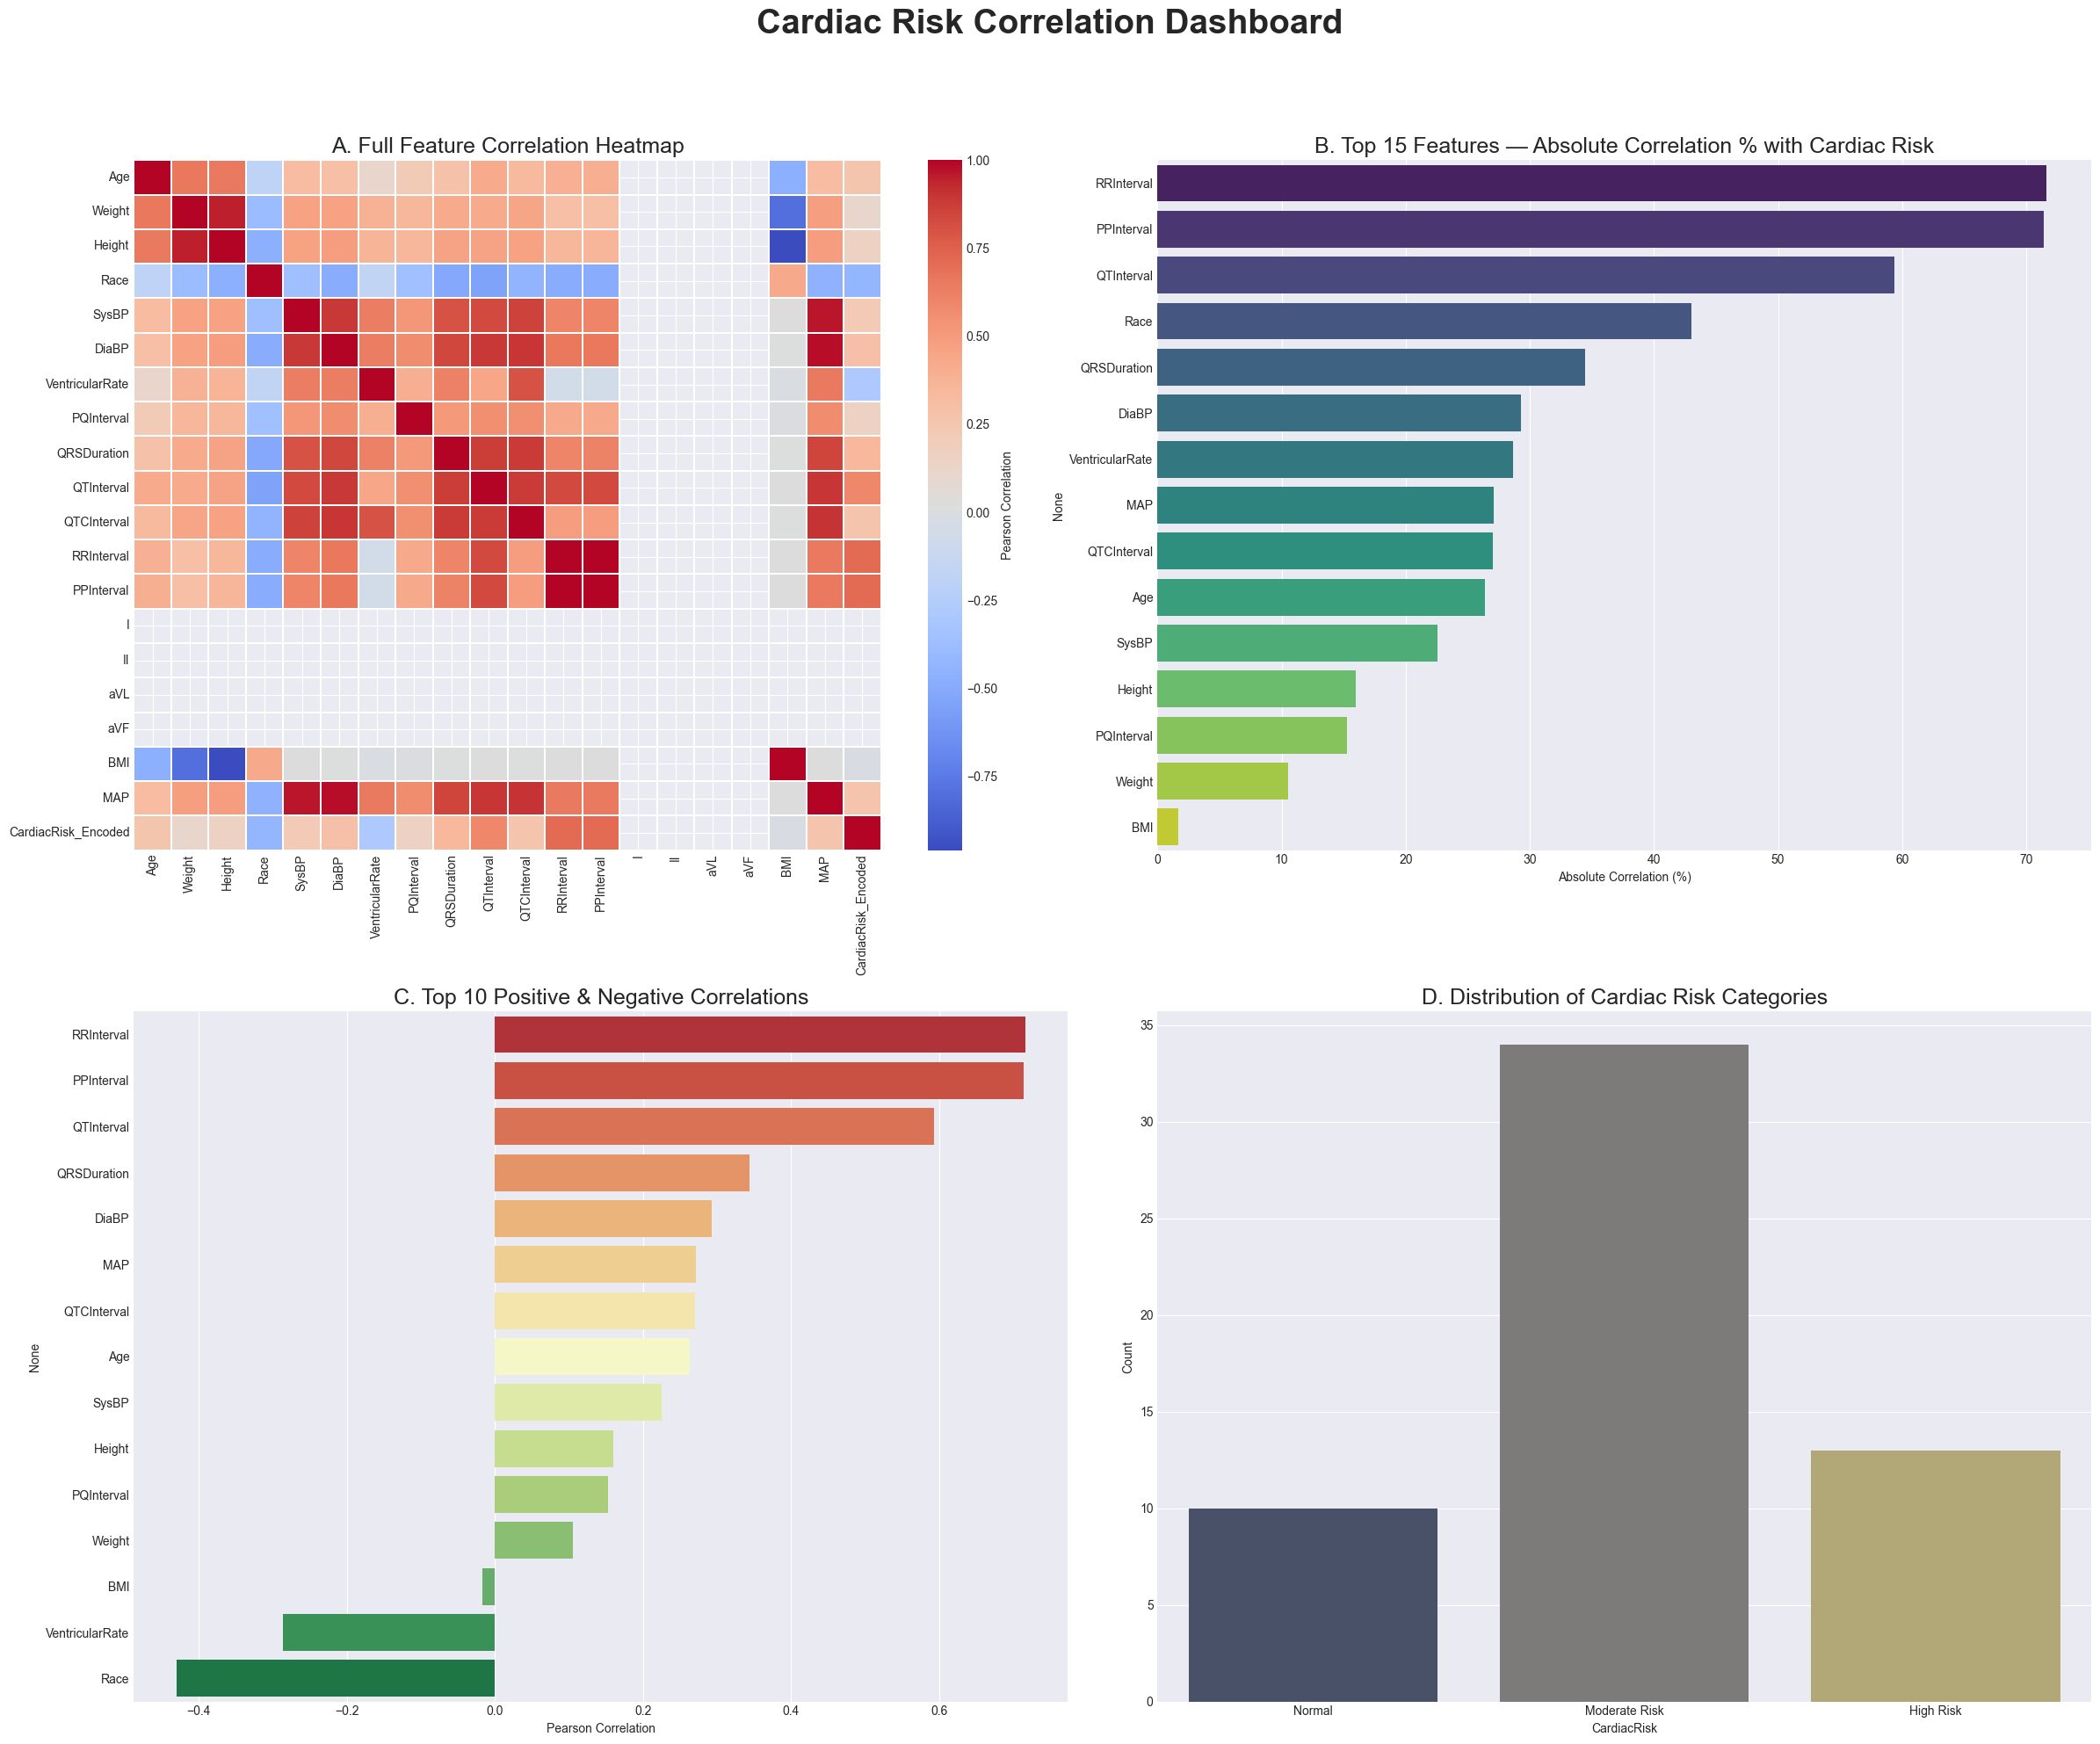

In [18]:
# 6d. Correlation Dashboard (composite)
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(24, 20))
fig.suptitle('Cardiac Risk Correlation Dashboard', fontsize=28, fontweight='bold', y=1.02)

# Plot 1: Heatmap
sns.heatmap(corr_matrix, ax=axes[0,0], annot=False, cmap='coolwarm',
            fmt='.2f', linewidths=.1, cbar_kws={'label': 'Pearson Correlation'})
axes[0,0].set_title('A. Full Feature Correlation Heatmap', fontsize=18)

# Plot 2: Correlation percentage bar chart
top_n = 15
top_corr_plot = correlation_df.head(top_n)
sns.barplot(x=top_corr_plot['Correlation (%)'], y=top_corr_plot.index,
            hue=top_corr_plot.index, ax=axes[0,1], palette='viridis', legend=False)
axes[0,1].set_title(f'B. Top {top_n} Features — Absolute Correlation % with Cardiac Risk', fontsize=18)
axes[0,1].set_xlabel('Absolute Correlation (%)')

# Plot 3: Positive and negative correlations
corr_for_plot = pf_df.select_dtypes(include=np.number).corr()['CardiacRisk_Encoded']\
    .drop('CardiacRisk_Encoded', errors='ignore')
top_pos = corr_for_plot.nlargest(10)
top_neg = corr_for_plot.nsmallest(10)
combined = pd.concat([top_pos, top_neg]).sort_values(ascending=False)
sns.barplot(x=combined.values, y=combined.index, hue=combined.index, ax=axes[1,0], palette='RdYlGn', legend=False)
axes[1,0].set_title('C. Top 10 Positive & Negative Correlations', fontsize=18)
axes[1,0].set_xlabel('Pearson Correlation')

# Plot 4: Risk distribution
risk_order = ['Normal', 'Moderate Risk', 'High Risk', 'Unknown']
counts = pf_df['CardiacRisk'].value_counts().sort_index()
sns.barplot(x=counts.index, y=counts.values, ax=axes[1,1],
            order=[r for r in risk_order if r in counts.index],
            hue=counts.index, palette='cividis', legend=False)
axes[1,1].set_title('D. Distribution of Cardiac Risk Categories', fontsize=18)
axes[1,1].set_ylabel('Count')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

---
## 7. Scientific Findings Report

In [19]:
report_df = correlation_df.drop('CardiacRisk_Encoded', errors='ignore')

print("--- SCIENTIFIC FINDINGS REPORT: CARDIAC RISK CORRELATION ANALYSIS ---\n")

# 1. Strongest ECG feature
ecg_feats = ['QTInterval', 'QRSDuration', 'PQInterval', 'VentricularRate',
             'QTCInterval', 'RRInterval', 'PPInterval']
ecg_corr = report_df[report_df.index.isin(ecg_feats)].sort_values('Abs Correlation', ascending=False)
if not ecg_corr.empty:
    s = ecg_corr.iloc[0]
    print(f"1. Strongest ECG Feature: {s.name} (r={s['Correlation']:.2f}, {s['Correlation (%)']:.2f}%)")
    print(f"   {s.name} is a critical ECG parameter. A {'positive' if s['Correlation']>0 else 'negative'} "
          f"correlation suggests {'longer' if s['Correlation']>0 else 'shorter'} intervals are "
          f"associated with {'higher' if s['Correlation']>0 else 'lower'} cardiac risk.\n")

# 2. Strongest physiological feature
phys_feats = ['Age', 'Weight', 'Height', 'SysBP', 'DiaBP', 'BMI', 'MAP']
phys_corr = report_df[report_df.index.isin(phys_feats)].sort_values('Abs Correlation', ascending=False)
if not phys_corr.empty:
    s = phys_corr.iloc[0]
    print(f"2. Strongest Physiological Feature: {s.name} (r={s['Correlation']:.2f}, {s['Correlation (%)']:.2f}%)")
    print(f"   {s.name} is a fundamental physiological indicator. Its strong "
          f"{'positive' if s['Correlation']>0 else 'negative'} correlation underscores "
          f"its importance in risk assessment.\n")

# 3. Top 5 features by strength
top5 = report_df.head(5)
print("3. Top 5 Features by Correlation Strength:")
for i, (feat, row) in enumerate(top5.iterrows()):
    print(f"   {i+1}. {feat} (r={row['Correlation']:.2f}, {row['Correlation (%)']:.2f}%)")
print("   These features are the most linearly influential factors on cardiac risk.\n")

# 4. Weakest 5 features
weak5 = report_df.tail(5)
print("4. Weakest 5 Features by Correlation Strength:")
for i, (feat, row) in enumerate(weak5.iterrows()):
    print(f"   {i+1}. {feat} (r={row['Correlation']:.2f}, {row['Correlation (%)']:.2f}%)")
print("   These features show minimal linear association with cardiac risk in this dataset.\n")

print("--- END OF REPORT ---")

--- SCIENTIFIC FINDINGS REPORT: CARDIAC RISK CORRELATION ANALYSIS ---

1. Strongest ECG Feature: RRInterval (r=0.72, 71.66%)
   RRInterval is a critical ECG parameter. A positive correlation suggests longer intervals are associated with higher cardiac risk.

2. Strongest Physiological Feature: DiaBP (r=0.29, 29.30%)
   DiaBP is a fundamental physiological indicator. Its strong positive correlation underscores its importance in risk assessment.

3. Top 5 Features by Correlation Strength:
   1. RRInterval (r=0.72, 71.66%)
   2. PPInterval (r=0.71, 71.40%)
   3. QTInterval (r=0.59, 59.35%)
   4. Race (r=-0.43, 43.04%)
   5. QRSDuration (r=0.34, 34.42%)
   These features are the most linearly influential factors on cardiac risk.

4. Weakest 5 Features by Correlation Strength:
   1. BMI (r=-0.02, 1.65%)
   2. I (r=nan, nan%)
   3. II (r=nan, nan%)
   4. aVL (r=nan, nan%)
   5. aVF (r=nan, nan%)
   These features show minimal linear association with cardiac risk in this dataset.

--- END OF 

---
## 8. Save Outputs

In [20]:
output_dir = "./outputs/"
os.makedirs(output_dir, exist_ok=True)

# Save heatmap
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt='.2f', linewidths=.1)
plt.title('Pearson Correlation Matrix', fontsize=18)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'correlation_heatmap.png'))
plt.close()

# Save dashboard
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(24, 20))
fig.suptitle('Cardiac Risk Correlation Dashboard', fontsize=28, fontweight='bold', y=1.02)
sns.heatmap(corr_matrix, ax=axes[0,0], annot=False, cmap='coolwarm', fmt='.2f', linewidths=.1)
axes[0,0].set_title('A. Correlation Heatmap', fontsize=18)
sns.barplot(x=correlation_df.head(15)['Correlation (%)'], y=correlation_df.head(15).index, hue=correlation_df.head(15).index, ax=axes[0,1], palette='viridis', legend=False)
axes[0,1].set_title('B. Top 15 Features by Correlation %', fontsize=18)
top_pos = pf_df.select_dtypes(include=np.number).corr()['CardiacRisk_Encoded'].drop('CardiacRisk_Encoded', errors='ignore').nlargest(10)
top_neg = pf_df.select_dtypes(include=np.number).corr()['CardiacRisk_Encoded'].drop('CardiacRisk_Encoded', errors='ignore').nsmallest(10)
sns.barplot(x=pd.concat([top_pos, top_neg]).sort_values(ascending=False).values,
            y=pd.concat([top_pos, top_neg]).sort_values(ascending=False).index, hue=pd.concat([top_pos, top_neg]).sort_values(ascending=False).index, ax=axes[1,0], palette='RdYlGn', legend=False)
axes[1,0].set_title('C. Top 10 Positive & Negative Correlations', fontsize=18)
counts = pf_df['CardiacRisk'].value_counts().sort_index()
sns.barplot(x=counts.index, y=counts.values, ax=axes[1,1],
            order=[r for r in ['Normal','Moderate Risk','High Risk','Unknown'] if r in counts.index],
            hue=counts.index, palette='cividis', legend=False)
axes[1,1].set_title('D. Risk Distribution', fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.savefig(os.path.join(output_dir, 'correlation_dashboard.png'))
plt.close()

# Save correlation tables
correlation_df.to_csv(os.path.join(output_dir, 'correlation_percentage_table.csv'))
correlation_df.head(10).to_csv(os.path.join(output_dir, 'top_correlated_features.csv'))

print(f"All outputs saved to '{output_dir}/'")

C:\Users\R.SELLAMUTHU\AppData\Local\Temp\ipykernel_22000\2571582003.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation_df.head(15)['Correlation (%)'], y=correlation_df.head(15).index, ax=axes[0,1], palette='viridis')
C:\Users\R.SELLAMUTHU\AppData\Local\Temp\ipykernel_22000\2571582003.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pd.concat([top_pos, top_neg]).sort_values(ascending=False).values,
C:\Users\R.SELLAMUTHU\AppData\Local\Temp\ipykernel_22000\2571582003.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=c

All outputs saved to './outputs//'


---
## 9. (Optional) Extract & Inspect SportDB2 Signals

In [21]:
zip_path = "SportDB2.zip"
extract_path = "SportDB2"

if os.path.exists(extract_path):
    print(f"'{extract_path}' already exists.")
elif os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(extract_path)
    print("Extraction complete.")
else:
    print("SportDB2 not found.")

'SportDB2' already exists.


Signal type: <class 'numpy.void'>
Number of signal components: 5
  Signal 1: shape (1794000, 1)
  Signal 2: shape (7176, 1)
  Signal 3: shape (7176, 1)
  Signal 4: shape (7176, 1)
  Signal 5: shape (1, 1)


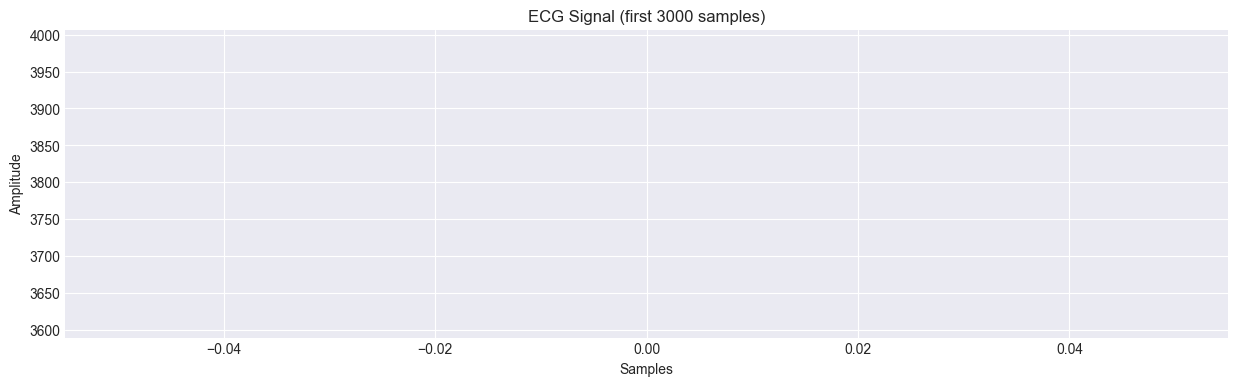

In [22]:
if os.path.exists('SportDB2/AMF/S1/CRD1/Data.mat'):
    data = loadmat('SportDB2/AMF/S1/CRD1/Data.mat')
    signals = data['Data'][0][0]

    print(f"Signal type: {type(signals)}")
    print(f"Number of signal components: {len(signals)}")
    for i, sig in enumerate(signals):
        print(f"  Signal {i+1}: shape {sig.shape}")

    # Plot first 3000 samples of the first ECG signal
    plt.figure(figsize=(15, 4))
    plt.plot(signals[0][0][:3000])
    plt.title("ECG Signal (first 3000 samples)")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    plt.show()
else:
    print("Data.mat not found. Skipping signal inspection.")